Hacemos los imports 

In [ ]:
import sys
!{sys.executable} -m pip install tensorflow
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install seaborn
!{sys.executable} -m pip install scikit-learn
!{sys.executable} -m pip install keras
!{sys.executable} -m pip install layers




  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached idna-3.13-py3-none-any.whl.metadata (8.0 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata

In [8]:
import sys
!{sys.executable} -m pip install tensorflow-directml-plugin

   ---------------------------------------- 0.0/9.0 MB ? eta -:--:--
   --------- ------------------------------ 2.1/9.0 MB 14.7 MB/s eta 0:00:01
   --------- ------------------------------ 2.1/9.0 MB 14.7 MB/s eta 0:00:01
   ------------- -------------------------- 3.1/9.0 MB 5.8 MB/s eta 0:00:02
   --------------------------- ------------ 6.3/9.0 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 9.0/9.0 MB 8.8 MB/s  0:00:01
   ---------------------------------------- 0.0/262.7 MB ? eta -:--:--
    --------------------------------------- 5.2/262.7 MB 29.0 MB/s eta 0:00:09
   - -------------------------------------- 12.8/262.7 MB 30.9 MB/s eta 0:00:09
   --- ------------------------------------ 19.9/262.7 MB 32.2 MB/s eta 0:00:08
   --- ------------------------------------ 19.9/262.7 MB 32.2 MB/s eta 0:00:08
   --- ------------------------------------ 19.9/262.7 MB 32.2 MB/s eta 0:00:08
   ---- ----------------------------------- 27.3/262.7 MB 21.6 MB/s eta 0:00:11
  

  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Users\\Victus-LP\\anaconda3\\envs\\TFG\\Lib\\site-packages\\tensorflow\\compiler\\tf2tensorrt\\_pywrap_py_utils.pyd'
Consider using the `--user` option or check the permissions.



In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers, optimizers, regularizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
df_partida = pd.read_csv("dataset.csv")

campos_borrar = ['Class', 'Brand', 'Acquisition', 'Concentration', 'Concentration_Class']

#Campos para adaptar el dataset de prueba a los datos de verdad
campos_nuevos = ["A_410", "B_435", "C_460", "D_485", "E_510", "F_535", "G_560", "H_585",
                    "R_610", "I_645", "S_680", "J_705", "T_730", "U_760", "V_810", "W_860",
                    "K_900", "L_940"]
df = pd.DataFrame()
df_modificado = df_partida.drop(campos_borrar, axis = 1)
y = df_partida['Class']

# posicion_campo = 0
# for i in range (len(campos_nuevos)):
#     df[campos_nuevos[i]] = df_modificado.iloc[:,[posicion_campo]]
#     posicion_campo = posicion_campo *2

X = df

#Para el XGBoost hay que hacer esto para que las clases sean un número y cambiarla en la asignación
le = LabelEncoder()
y_raw = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X , y_raw ,test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype('float32')
X_test_scaled = scaler.transform(X_test).astype('float32')

#Neuronas capa de salida
num_clases = len(np.unique(y_train))

In [4]:
def create_dataset(X, y, batch_size=256, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((X,y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [5]:
train_ds = create_dataset(X_train_scaled, y_train)
test_ds = create_dataset(X_test_scaled, y_test, shuffle=False)

Iniciando entrenamiento...
Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1402 - loss: 2.4137 - val_accuracy: 0.1489 - val_loss: 2.3633 - learning_rate: 0.0010
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1452 - loss: 2.3726 - val_accuracy: 0.1478 - val_loss: 2.3609 - learning_rate: 0.0010
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1510 - loss: 2.3656 - val_accuracy: 0.1546 - val_loss: 2.3612 - learning_rate: 0.0010
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1519 - loss: 2.3637 - val_accuracy: 0.1555 - val_loss: 2.3602 - learning_rate: 0.0010
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1511 - loss: 2.3622 - val_accuracy: 0.1530 - val_loss: 2.3588 - learning_rate: 0.0010
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1527 - loss: 2.3614 - val_accuracy: 0.1528 - val_loss: 2.3590 - learning_rate: 0.0010
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accurac

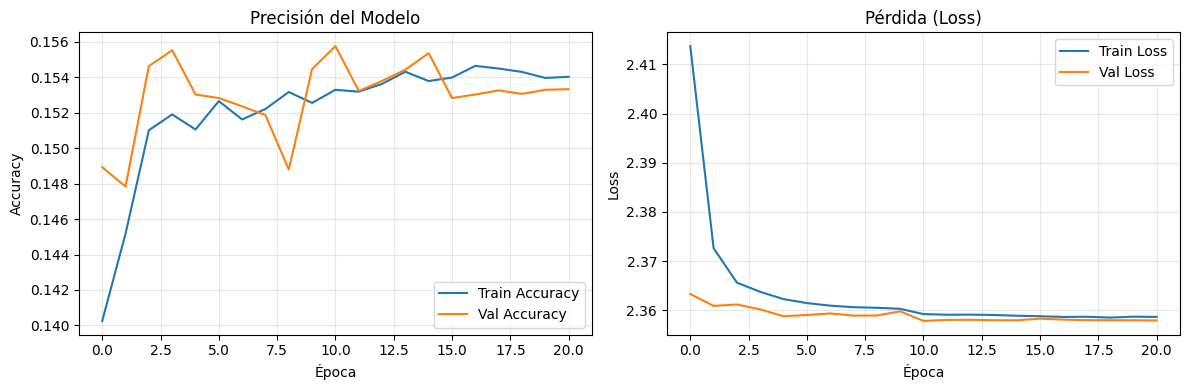


EVALUACIÓN EN TEST

Loss:     2.3578
Accuracy: 0.1558  (15.58%)

REPORTE POR CLASE
              precision    recall  f1-score   support

           0      0.000     0.000     0.000      2766
           1      0.166     0.016     0.030      4100
           2      0.000     0.000     0.000      2661
           3      0.173     0.653     0.274      4514
           4      0.132     0.397     0.198      4177
           5      0.000     0.000     0.000      2015
           6      0.000     0.000     0.000      2112
           7      0.000     0.000     0.000      2167
           8      0.000     0.000     0.000      2045
           9      0.000     0.000     0.000      1470
          10      0.000     0.000     0.000      1510
          11      0.000     0.000     0.000       463

    accuracy                          0.156     30000
   macro avg      0.039     0.089     0.042     30000
weighted avg      0.067     0.156     0.073     30000



c:\Users\Victus-LP\anaconda3\envs\TFG\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Victus-LP\anaconda3\envs\TFG\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Victus-LP\anaconda3\envs\TFG\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

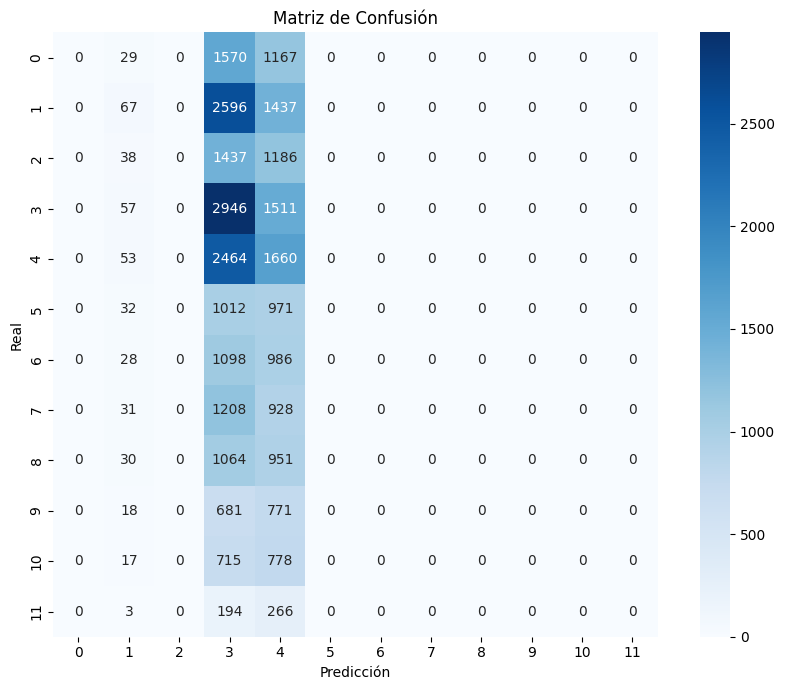

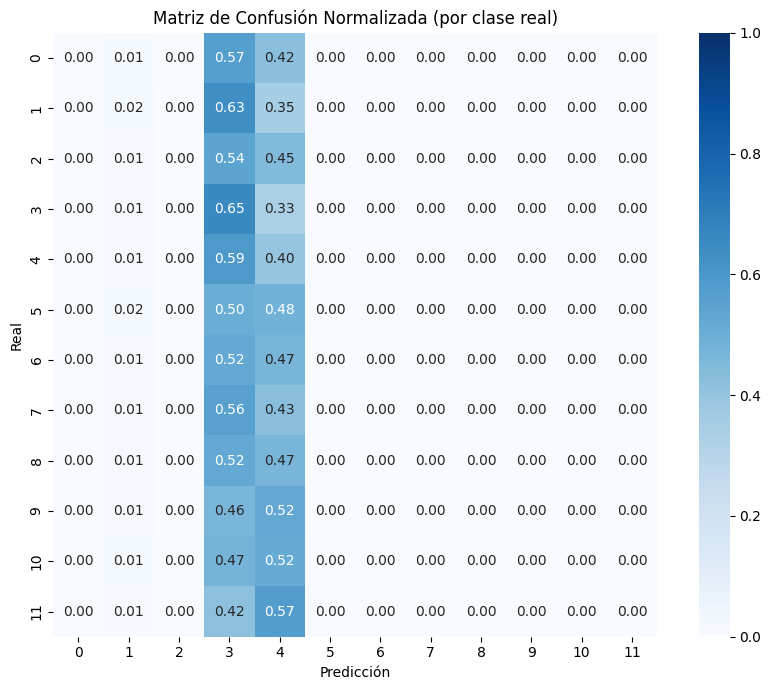


CONFIANZA DEL MODELO
Confianza media cuando acierta: 0.158
Confianza media cuando falla:   0.153


In [10]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    #Capa 1:
    layers.Dense(512, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    
    #Capa 2:                            # Regularización contra overfitting
    layers.Dense(256, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.2),
    
    #Capa 3:
    layers.Dense(128, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.3),
    
    #Capa de salida
    layers.Dense(num_clases, activation='softmax')    # Softmax para multiclase
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Checpoints para guardar el mejor resultado
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "mejor_resultado.keras",
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    ),
    checkpoint_cb
]

# Calcular pesos basados en y_train
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

print("Iniciando entrenamiento...")
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

# Curbas de entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EVALUACIÓN EN TEST")
print("="*60)

loss, accuracy = model.evaluate(test_ds, verbose=0)
print(f"\nLoss:     {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")

# Predicciones
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Métricas por clase
print("\n" + "="*60)
print("REPORTE POR CLASE")
print("="*60)
print(classification_report(y_true, y_pred, digits=3))

# Matroz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    square=True
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    cbar=True,
    square=True,
    vmin=0,
    vmax=1
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión Normalizada (por clase real)')
plt.tight_layout()
plt.show()

confianzas = np.max(y_pred_probs, axis=1)
aciertos = (y_pred == y_true)

print("\n" + "="*60)
print("CONFIANZA DEL MODELO")
print("="*60)
print(f"Confianza media cuando acierta: {confianzas[aciertos].mean():.3f}")
print(f"Confianza media cuando falla:   {confianzas[~aciertos].mean():.3f}")

🔧 CONFIGURANDO PRUEBAS DE HIPERPARÁMETROS

📋 Total de configuraciones a probar: 11


🧪 PRUEBA 1/11
  → LR: 0.001, Optimizer: adam, Dropout: 0.2, L2: 0, Act: swish, Units: 512
  ✅ Completado! Val Acc: 0.2422, Test Acc: 0.2433

🧪 PRUEBA 2/11
  → LR: 0.0005, Optimizer: adam, Dropout: 0.2, L2: 0, Act: swish, Units: 512
  ✅ Completado! Val Acc: 0.2429, Test Acc: 0.2426

🧪 PRUEBA 3/11
  → LR: 0.0001, Optimizer: adam, Dropout: 0.2, L2: 0, Act: swish, Units: 512
  ✅ Completado! Val Acc: 0.2371, Test Acc: 0.2366

🧪 PRUEBA 4/11
  → LR: 0.001, Optimizer: adam, Dropout: 0.3, L2: 0, Act: swish, Units: 1024
  ✅ Completado! Val Acc: 0.2436, Test Acc: 0.2428

🧪 PRUEBA 5/11
  → LR: 0.001, Optimizer: adam, Dropout: 0.2, L2: 0, Act: swish, Units: 256
  ✅ Completado! Val Acc: 0.2427, Test Acc: 0.2441

🧪 PRUEBA 6/11
  → LR: 0.001, Optimizer: adam, Dropout: 0.2, L2: 0.0001, Act: swish, Units: 512
  ✅ Completado! Val Acc: 0.2454, Test Acc: 0.2478

🧪 PRUEBA 7/11
  → LR: 0.0005, Optimizer: adam, Dropout: 0.1, 

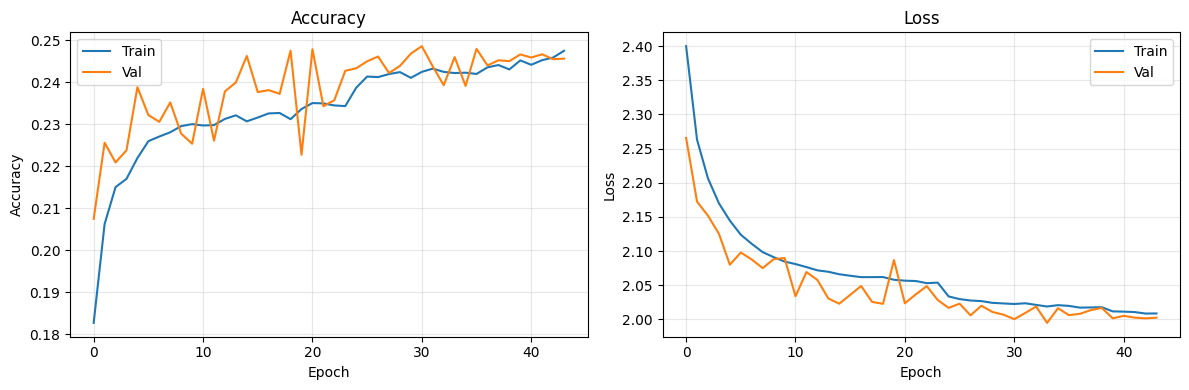


📈 EVALUACIÓN FINAL EN TEST

Loss:     1.9950
Accuracy: 0.2460 (24.60%)

📋 REPORTE POR CLASE
              precision    recall  f1-score   support

           0      0.153     0.098     0.119      2766
           1      0.256     0.334     0.290      4100
           2      0.146     0.187     0.164      2661
           3      0.554     0.625     0.588      4514
           4      0.224     0.139     0.172      4177
           5      0.157     0.106     0.126      2015
           6      0.124     0.073     0.092      2112
           7      0.122     0.066     0.086      2167
           8      0.123     0.152     0.136      2045
           9      0.234     0.218     0.226      1470
          10      0.137     0.254     0.178      1510
          11      0.234     0.680     0.349       463

    accuracy                          0.246     30000
   macro avg      0.206     0.244     0.210     30000
weighted avg      0.235     0.246     0.233     30000



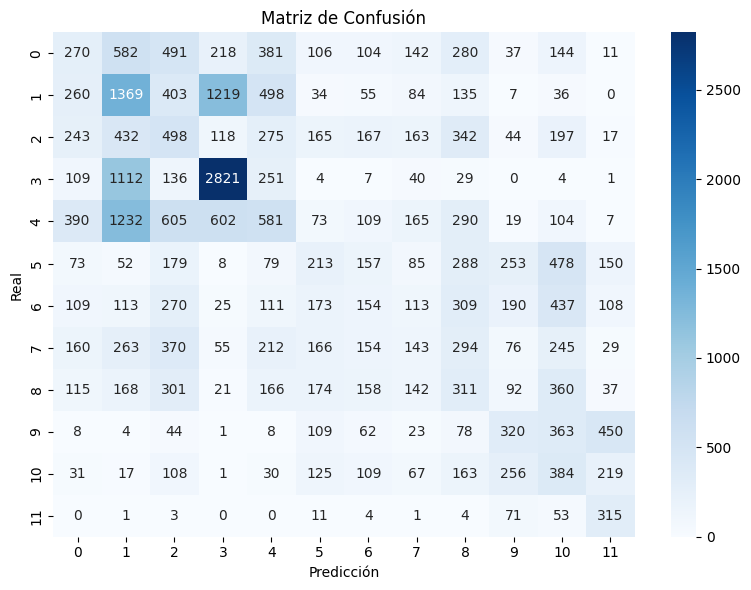


✅ ¡Proceso completado!


In [9]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow.keras import layers, regularizers, callbacks, optimizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ==========================================
# 🧪 FUNCIÓN DE ENTRENAMIENTO SIMPLE
# ==========================================
def train_and_evaluate(lr, opt, dropout, l2, act, units, epochs=50):
    print(f"  → LR: {lr}, Optimizer: {opt}, Dropout: {dropout}, L2: {l2}, Act: {act}, Units: {units}")
    
    start = time.time()
    
    # Construir modelo
    model = tf.keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        
        layers.Dense(units, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(l2) if l2 > 0 else None),
        layers.BatchNormalization(),
        layers.Activation(act),
        layers.Dropout(dropout),
        
        layers.Dense(units // 2, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(l2) if l2 > 0 else None),
        layers.BatchNormalization(),
        layers.Activation(act),
        layers.Dropout(dropout * 1.2),
        
        layers.Dense(num_clases, activation='softmax')
    ])
    
    # Optimizador
    if opt == 'adam':
        optimizer = optimizers.Adam(learning_rate=lr)
    elif opt == 'adamw':
        optimizer = optimizers.AdamW(learning_rate=lr, weight_decay=l2 if l2 > 0 else 1e-4)
    elif opt == 'sgd':
        optimizer = optimizers.SGD(learning_rate=lr, momentum=0.9)
    
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # Callbacks
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=0)
    ]
    
    # Pesos de clase
    weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    cw = dict(enumerate(weights))
    
    # Entrenar
    history = model.fit(
        train_ds, validation_data=test_ds, epochs=epochs,
        callbacks=cb, class_weight=cw, verbose=0
    )
    
    # Evaluar
    loss, acc = model.evaluate(test_ds, verbose=0)
    
    elapsed = time.time() - start
    
    return {
        'lr': lr, 'opt': opt, 'dropout': dropout, 'l2': l2, 'act': act, 'units': units,
        'val_loss': history.history['val_loss'][-1],
        'val_acc': history.history['val_accuracy'][-1],
        'test_acc': acc,
        'time_s': round(elapsed, 2)
    }

# ==========================================
# 📊 CONFIGURACIÓN DE PRUEBAS
# ==========================================
print("="*60)
print("🔧 CONFIGURANDO PRUEBAS DE HIPERPARÁMETROS")
print("="*60)

# Lista de configuraciones a probar
configuraciones = [
    # Configuración base (tu modelo actual)
    dict(lr=0.001, opt='adam', dropout=0.2, l2=0, act='swish', units=512),
    
    # Variaciones de learning rate
    dict(lr=0.0005, opt='adam', dropout=0.2, l2=0, act='swish', units=512),
    dict(lr=0.0001, opt='adam', dropout=0.2, l2=0, act='swish', units=512),
    
    # Variaciones de arquitectura
    dict(lr=0.001, opt='adam', dropout=0.3, l2=0, act='swish', units=1024),
    dict(lr=0.001, opt='adam', dropout=0.2, l2=0, act='swish', units=256),
    
    # Con regularización L2
    dict(lr=0.001, opt='adam', dropout=0.2, l2=1e-4, act='swish', units=512),
    dict(lr=0.0005, opt='adam', dropout=0.1, l2=1e-3, act='swish', units=512),
    
    # Otros optimizadores
    dict(lr=0.001, opt='sgd', dropout=0.2, l2=0, act='relu', units=512),
    dict(lr=0.0005, opt='adamw', dropout=0.2, l2=1e-4, act='gelu', units=512),
    
    # Activaciones alternativas
    dict(lr=0.001, opt='adam', dropout=0.2, l2=0, act='gelu', units=512),
    dict(lr=0.001, opt='adam', dropout=0.2, l2=0, act='relu', units=512),
]

print(f"\n📋 Total de configuraciones a probar: {len(configuraciones)}\n")

# ==========================================
# 🚀 EJECUTAR PRUEBAS
# ==========================================
resultados = []

for i, config in enumerate(configuraciones, 1):
    print(f"\n{'='*60}")
    print(f"🧪 PRUEBA {i}/{len(configuraciones)}")
    print(f"{'='*60}")
    
    try:
        res = train_and_evaluate(**config, epochs=50)
        resultados.append(res)
        print(f"  ✅ Completado! Val Acc: {res['val_acc']:.4f}, Test Acc: {res['test_acc']:.4f}")
    except Exception as e:
        print(f"  ❌ Error: {e}")
        continue

# ==========================================
# 📈 MOSTRAR RESULTADOS
# ==========================================
if resultados:
    df = pd.DataFrame(resultados)
    
    print("\n" + "="*60)
    print("📊 RESULTADOS ORDENADOS POR VALIDATION ACCURACY")
    print("="*60)
    print(df.sort_values('val_acc', ascending=False).to_string(index=False))
    
    # Guardar
    df.to_csv('resultados_hyperparametros.csv', index=False)
    print(f"\n💾 Resultados guardados en 'resultados_hyperparametros.csv'")
    
    # ==========================================
    # 🏆 MEJOR MODELO - EVALUACIÓN DETALLADA
    # ==========================================
    mejor = df.loc[df['val_acc'].idxmax()]
    print("\n" + "="*60)
    print("🏆 MEJOR CONFIGURACIÓN ENCONTRADA")
    print("="*60)
    print(f"LR: {mejor['lr']}, Optimizer: {mejor['opt']}")
    print(f"Dropout: {mejor['dropout']}, L2: {mejor['l2']}")
    print(f"Activación: {mejor['act']}, Units: {mejor['units']}")
    print(f"Val Accuracy: {mejor['val_acc']:.4f}")
    print(f"Test Accuracy: {mejor['test_acc']:.4f}")
    
    # Entrenar el mejor modelo con visualización
    print("\n" + "="*60)
    print("🎯 ENTRENANDO MEJOR MODELO (con visualización)")
    print("="*60)
    
    # Construir mejor modelo
    model = tf.keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(int(mejor['units']), kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(mejor['l2']) if mejor['l2'] > 0 else None),
        layers.BatchNormalization(),
        layers.Activation(mejor['act']),
        layers.Dropout(mejor['dropout']),
        
        layers.Dense(int(mejor['units']) // 2, kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(mejor['l2']) if mejor['l2'] > 0 else None),
        layers.BatchNormalization(),
        layers.Activation(mejor['act']),
        layers.Dropout(mejor['dropout'] * 1.2),
        
        layers.Dense(num_clases, activation='softmax')
    ])
    
    if mejor['opt'] == 'adam':
        optimizer = optimizers.Adam(learning_rate=mejor['lr'])
    elif mejor['opt'] == 'adamw':
        optimizer = optimizers.AdamW(learning_rate=mejor['lr'])
    elif mejor['opt'] == 'sgd':
        optimizer = optimizers.SGD(learning_rate=mejor['lr'], momentum=0.9)
    
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # Callbacks con checkpoint
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
        callbacks.ModelCheckpoint('mejor_modelo_final.keras', save_best_only=True, monitor='val_loss', mode='min')
    ]
    
    weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    cw = dict(enumerate(weights))
    
    # Entrenar con verbose=1 para ver progreso
    history = model.fit(
        train_ds, validation_data=test_ds, epochs=50,
        callbacks=cb, class_weight=cw, verbose=1
    )
    
    # ==========================================
    # 📊 GRÁFICAS DE ENTRENAMIENTO
    # ==========================================
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # 📈 EVALUACIÓN FINAL EN TEST
    # ==========================================
    print("\n" + "="*60)
    print("📈 EVALUACIÓN FINAL EN TEST")
    print("="*60)
    
    loss, accuracy = model.evaluate(test_ds, verbose=0)
    print(f"\nLoss:     {loss:.4f}")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # Predicciones
    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.concatenate([y for x, y in test_ds], axis=0)
    
    # Reporte por clase
    print("\n" + "="*60)
    print("📋 REPORTE POR CLASE")
    print("="*60)
    print(classification_report(y_true, y_pred, digits=3))
    
    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()
    
    print("\n✅ ¡Proceso completado!")
else:
    print("\n❌ No se completó ninguna prueba exitosamente.")